<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
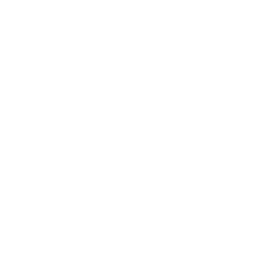
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Identifiering av marknadsregimer</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Kvantitativ finans / Kapitalförvaltning &nbsp;|&nbsp; mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Detta exempel använder **PROC ACECLUS** för att hitta den latenta struktur som separerar marknadsregimer, och klustrar sedan på den. Från 100 veckovisa observationer av 10 marknadsvariabler (aktieavkastning och volatilitet, kredit- och high yield-spreadar, 2y/10y-kurvan, dollarn, råvaror och en VIX-förändring) skattar ACECLUS en approximativ inomregim-kovarians *utan* att använda någon regimetikett, och härleder kanoniska variabler längs vilka regimerna dras isär.

Vid tröskeln P=0.02 konvergerar algoritmen på två iterationer och behåller **tre kanoniska dimensioner**, som tillsammans står för hela spridningen mellan regimerna (egenvärdesproportioner 57.8%, 24.4%, 17.8%). En lösare tröskel P=0.05 översläter kovariansen och **kollapsar strukturen till en enda dimension** — en nyttig påminnelse om att tröskeln påtagligt formar resultatet.

Att mata in de tre kanoniska variablerna i **PROC FASTCLUS** (k=4) ger en tydlig ordning av de 100 veckorna efter stressgrad (total R² = 0.51, pseudo-F = 33.2): en lugn kärna på 62 veckor, en återhämtande grupp på 22 veckor med avtagande volatilitet, en grupp på 12 veckor med förhöjd stress, och en grupp på 4 veckor med djup kris där high yield-spreadar i genomsnitt är ~1,514 bps. Dessa tilldelningar exporteras för efterföljande konditionering av portföljrisk.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | Veckovisa observationer av marknadsvariabler över tillgångsslag | 100 |
| Variabler: eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

Serien genereras av en Markov-regimväxlingsprocess med fem tillstånd (hausse-expansion, sen cykel, risk-off, kris, återhämtning) med regimbetingade variabelfördelningar. Vid körning utan licens begränsas variabeltabellen till de första 100 veckovisa observationerna (~2 år) — ett hausse-dominerat fönster som också besöker en kort kris och återhämtning. Veckovisa avkastningar och nivåförändringar står i stället för prisrörelser vid veckans slut; spreadar anges i baspunkter och volatilitet är ett VIX-liknande index.

---

In [1]:
/* --------------------------------------------------------
   Generera en veckovis multi-tillgångs marknadshistorik med
   fem inbäddade regimtillstånd drivna av en Markov-
   växlingsprocess. Detta exempel körs olicensierat, så
   variabeltabellen nedan begränsas till de första 100
   veckovisa observationerna (~2 år) -- ett hausse-dominerat
   fönster brutet av en kort kris och återhämtning.
   -------------------------------------------------------- */
data work.market_weekly;
    CALL streaminit(42);
    /* 5 regimer: 1=Hausse, 2=Sen cykel, 3=Risk-off, 4=Kris, 5=Återhämtning */
    FÄLT regime_names[5] $24 _temporary_
        ('HAUSSE_EXPANSION' 'SEN_CYKEL' 'RISK_OFF'
         'KRIS' 'ÅTERHÄMTNING');
    BEHÅLL_VÄRDE current_regime 1;
    GÖR week_id = 1 TILL 5000;
        /* Markov regimväxling */
        u = rand('uniform');
        OM current_regime = 1 SÅ GÖR; /* Hausse: långlivad */
            OM u > 0.97 SÅ current_regime = 2;
        SLUT;
        ANNARS OM current_regime = 2 SÅ GÖR; /* Sen cykel */
            OM u > 0.92 SÅ current_regime = 3;
        SLUT;
        ANNARS OM current_regime = 3 SÅ GÖR; /* Risk-off */
            OM u > 0.80 SÅ current_regime = 4;
            ANNARS OM u < 0.10 SÅ current_regime = 1;
        SLUT;
        ANNARS OM current_regime = 4 SÅ GÖR; /* Kris: kort */
            OM u > 0.75 SÅ current_regime = 5;
        SLUT;
        ANNARS OM current_regime = 5 SÅ GÖR; /* Återhämtning */
            OM u > 0.85 SÅ current_regime = 1;
        SLUT;
        regime_label = regime_names[current_regime];
        /* Regimbetingade variabelfördelningar */
        OM current_regime = 1 SÅ GÖR;  /* Hausse */
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        SLUT;
        ANNARS OM current_regime = 2 SÅ GÖR;  /* Sen cykel */
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        SLUT;
        ANNARS OM current_regime = 3 SÅ GÖR;  /* Risk-off */
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        SLUT;
        ANNARS OM current_regime = 4 SÅ GÖR;  /* Kris */
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        SLUT;
        ANNARS GÖR;  /* Återhämtning */
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        SLUT;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        OM week_id = 1 SÅ vix_chg = 0;
        UTDATA;
    SLUT;
    TA_BORT u;
    BYT_NAMN credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
KÖR;



NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.38 seconds
  cpu   1.38 seconds


---

In [2]:
/* --------------------------------------------------------
   Baslinjens marknadsvariabelfördelningar per regim
   -------------------------------------------------------- */
TITEL "Baslinjens variabelfördelningar per regim";
PROCEDUR MEDELVÄRDEN data=work.market_weekly n mean std MIN MAX;
    KLASS regime_label;
    VARIABEL eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    ETIKETT regime_label="Marknadsregim"
          eq_return_pct="Aktieavkastning (%)"
          eq_vol_idx="Aktievolatilitetsindex"
          credit_spread_bps="Kreditspread (bps)"
          hy_spread_bps="High yield-spread (bps)"
          term_spread="Löptidsspread"
          vix_chg="VIX-förändring";
KÖR;
TITEL;


                                       Baslinjens variabelfördelningar per regim                                        

                                                  The MEANS Procedure

                                 Analysis Variable : eq_return_pct Aktieavkastning (%)

        Marknadsregim             N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------------
        HAUSSE_EXPANSION             28      0.2860000      1.0226518     -1.5980000      2.2150000
        KRIS                         12     -2.3403333      3.9436692     -8.0160000      3.7360000
        RISK_OFF                     17     -0.8447059      1.2832441     -3.3850000      1.1810000
        SEN_CYKEL                    39      0.0364359      1.9733801     -4.6010000      3.7030000
        ÅTERHÄMTNI                    4      0.0077500      1.5951747     -0.8330000      2.4000000
        -----------


NOTE: Option TITLE changed to Baslinjens variabelfördelningar per regim.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


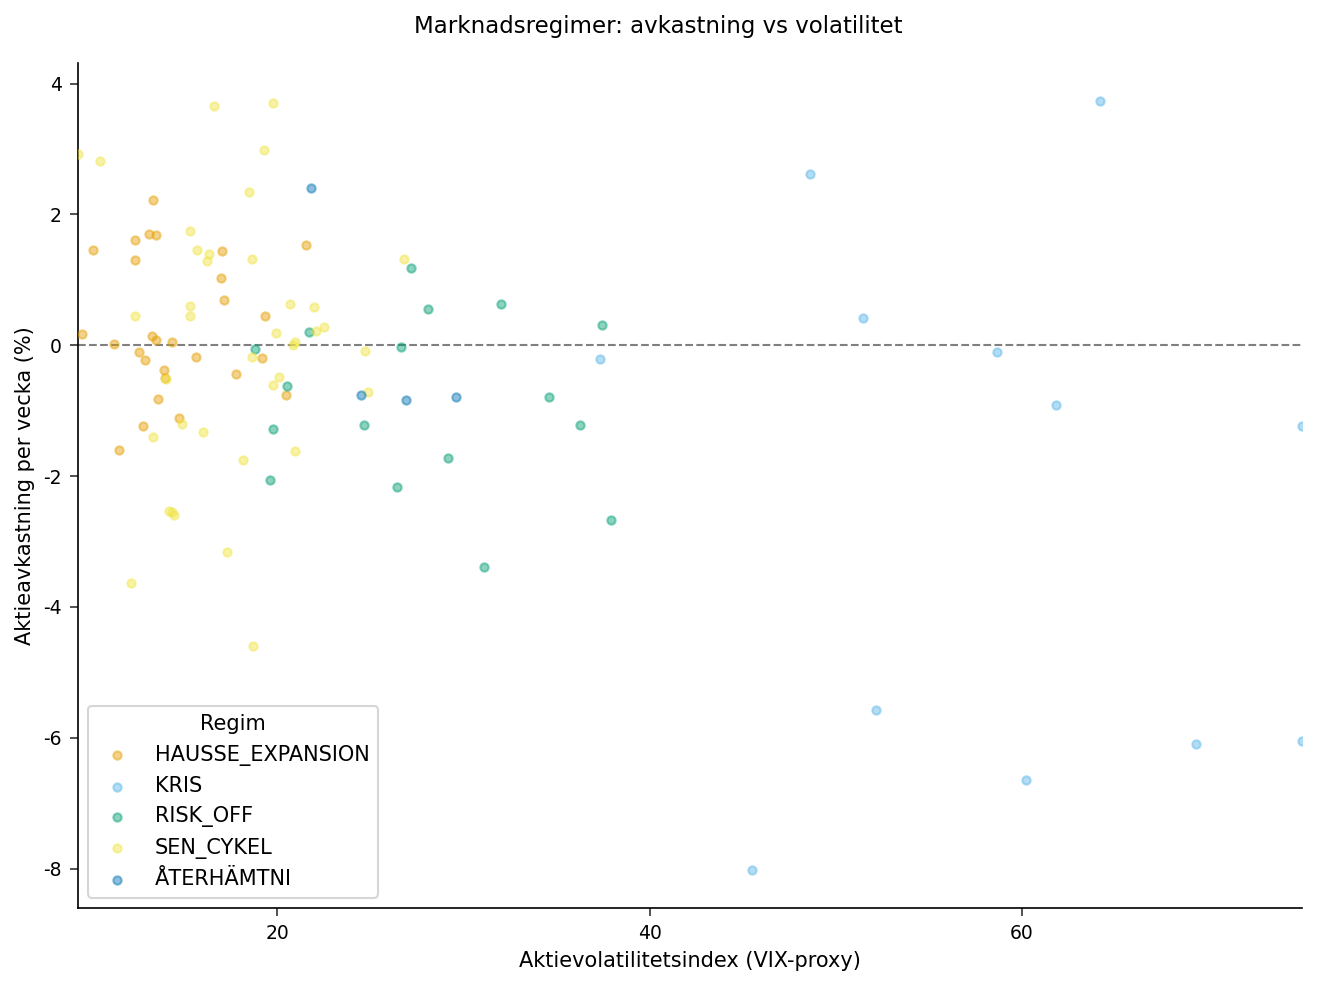

In [3]:
/* --------------------------------------------------------
   Aktieavkastning vs volatilitetsindex per regimetikett
   -------------------------------------------------------- */
PROCEDUR SGPLOT data=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUP=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS ETIKETT='Aktievolatilitetsindex (VIX-proxy)';
    YAXIS ETIKETT='Aktieavkastning per vecka (%)';
    keylegend / TITEL='Regim';
    TITEL 'Marknadsregimer: avkastning vs volatilitet';
KÖR;
TITEL;


---

In [4]:
/* --------------------------------------------------------
   Approximativ inomregim-kovariansskattning. ACECLUS
   skattar den poolade inomkluster-kovariansen utan att
   känna klusteretiketterna, och härleder sedan kanoniska
   variabler som separerar regimerna. P=0.02 sätter
   tröskeln för parvisa avstånd: bara de närmaste ~2 %
   av observationsparen behandlas som samma regim.
   -------------------------------------------------------- */
PROCEDUR aceclus data=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    VARIABEL eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
KÖR;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* --------------------------------------------------------
   Känslighetskontroll vid P=0.05 -- en lösare samma-regim-
   tröskel drar in fler par och blåser upp den skattade
   inomregim-kovariansen. Jämför den kanoniska strukturen
   (egenvärden och behållna dimensioner) mot P=0.02-lösningen.
   -------------------------------------------------------- */
PROCEDUR aceclus data=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    VARIABEL eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
KÖR;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* --------------------------------------------------------
   k-means på ACECLUS kanoniska variabler. ACECLUS behöll
   tre kanoniska dimensioner (Can1-Can3), så klustringen
   körs på dem. Fyra kluster riktar in sig på de fyra
   välbefolkade marknadstillstånden.
   -------------------------------------------------------- */
PROCEDUR FASTCLUS data=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    VARIABEL can1 can2 can3;
KÖR;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4                   4         1.7742             4.0619              2         4.1923

                                    


NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                          Regimkluster vs faktisk regimetikett                                          

                                                   The FREQ Procedure

Table of Kluster by Marknadsregim

Kluster |HAUSSE_EXPANSION |            KRIS |        RISK_OFF |       SEN_CYKEL |      ÅTERHÄMTNI |            Total
--------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------
1       |               2 |               4 |               4 |               2 |               0 |               12
        |            2.00 |            4.00 |            4.00 |            2.00 |            0.00 |            12.00
--------+-----------------+-----------------+-----------------+-----------------+-----------------+-----------------
2       |              21 |               3 |               7 |              28 |               3 |               62
        |           21.00 |            3.00 |            7.00 |       


NOTE: Option TITLE changed to Regimkluster vs faktisk regimetikett.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


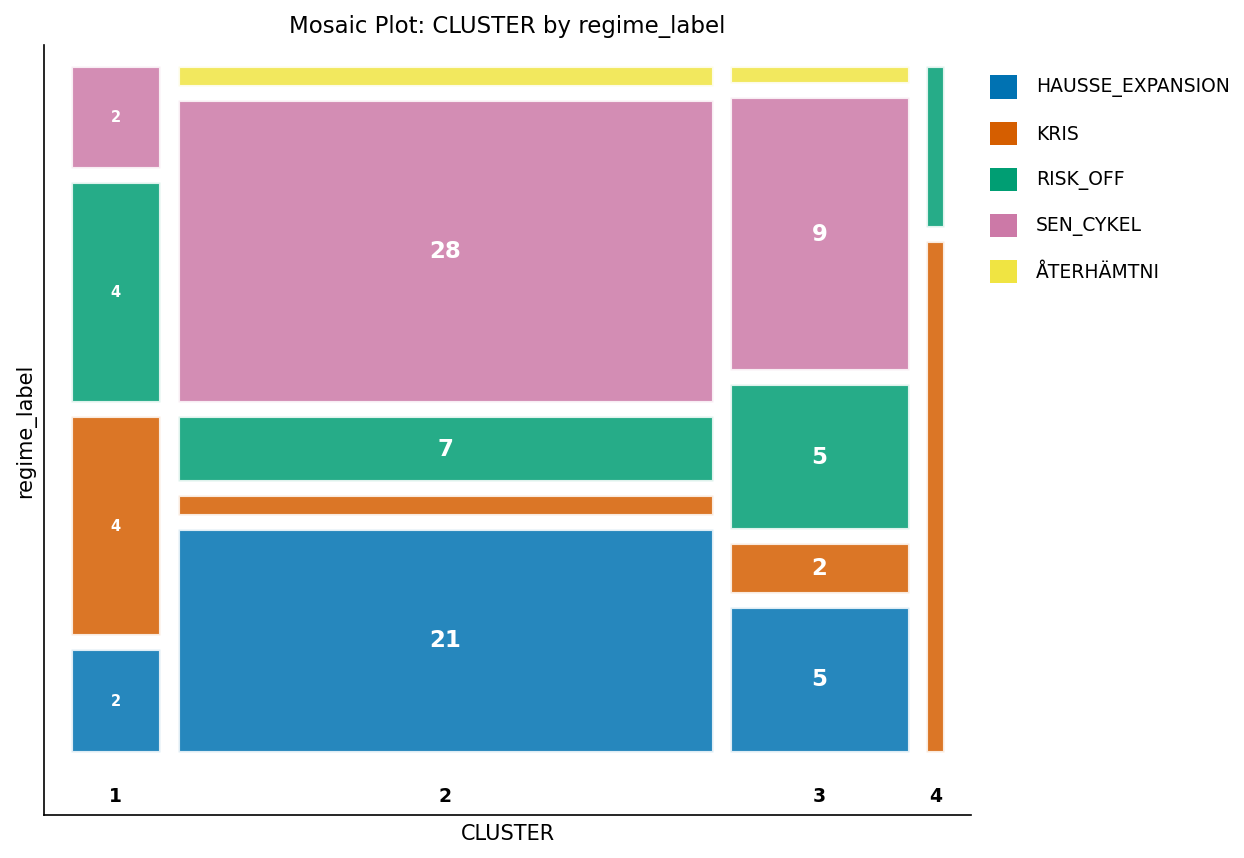

In [7]:
/* --------------------------------------------------------
   Validera tilldelade kluster mot kända regimetiketter
   från datagenereringen
   -------------------------------------------------------- */
TITEL "Regimkluster vs faktisk regimetikett";
PROCEDUR FREKVENSER data=work.regime_assignments;
    TABLES CLUSTER * regime_label / norow nocol;
    ETIKETT CLUSTER="Kluster" regime_label="Marknadsregim";
KÖR;
TITEL;


In [8]:
/* --------------------------------------------------------
   Profilera regimernas variabelmedelvärden för tolkning
   -------------------------------------------------------- */
TITEL "Klusterprofiler: variabelmedelvärden";
PROCEDUR MEDELVÄRDEN data=work.regime_assignments mean;
    KLASS CLUSTER;
    VARIABEL eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    ETIKETT CLUSTER="Kluster"
          eq_return_pct="Aktieavkastning (%)"
          eq_vol_idx="Aktievolatilitetsindex"
          credit_spread_bps="Kreditspread (bps)"
          hy_spread_bps="High yield-spread (bps)"
          term_spread="Löptidsspread"
          vix_chg="VIX-förändring";
KÖR;
TITEL;


                                          Klusterprofiler: variabelmedelvärden                                          

                                                  The MEANS Procedure

                                             Analysis Variable : eq_return_pct Aktieavkastning (%)

                                                          N
                                             Kluster    Obs            Mean
                                             ------------------------------
                                             1           12      -2.0955000
                                             2           62      -0.3638871
                                             3           22       0.7421364
                                             4            4      -0.4010000
                                             ------------------------------

                                             Analysis Variable : eq_vol_idx Aktievolatilitetsindex

              


NOTE: Option TITLE changed to Klusterprofiler: variabelmedelvärden.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Tolkning

**ACECLUS kanoniska struktur.** På urvalet av 100 veckor konvergerade PROC ACECLUS (P=0.02, tröskel = 2.578941) på två iterationer och producerade tre kanoniska variabler. Deras egenvärden för `Inv(ACE)*(COV-ACE)` är 0.0219, 0.0093 och 0.0067, dvs. proportioner på 57.8%, 24.4% och 17.8% (kumulativt 100%). Den första kanoniska axeln bär den dominerande risk-on/risk-off-kontrasten; den andra och tredje förfinar den. Eftersom aktievolatilitets- och spreadvariablerna samvarierar starkt, viker ACECLUS in den delade variationen i inomregim-kovariansen så att de kanoniska axlarna återspeglar genuin separation mellan regimer snarare än gemensam skala.

**Tröskelkänslighet.** Omkörning vid P=0.05 höjer avståndströskeln till 2.899704, vilket drar 4,949 av de 4,950 observationsparen innanför gränsen. Den skattade inomregim-kovariansen är då nästan lika med den totala kovariansen, och den kanoniska strukturen **kollapsar till en enda dimension** (ett egenvärde, 0.0096, på 100%). Lösningarna för P=0.02 och P=0.05 är därför *inte* utbytbara här — en lösare tröskel raderar de finare regimaxlarna, så den snävare tröskeln är den mer informativa specifikationen för detta urval.

**Klustring på de kanoniska variablerna.** PROC FASTCLUS (k=4) på Can1–Can3 ger en total R² på 0.5089 och en pseudo-F på 33.16. Can2 gör det mesta av separationsarbetet (R² = 0.626), Can1 bidrar måttligt (R² = 0.359), och Can3 tillför i stort sett ingenting (R² = 0.000) — förenligt med att endast två axlar bär en stark signal. De fyra klustren ordnar sig som en marknadsstressgradient:

| Kluster | n | Genomsn. aktieavk. | Genomsn. VIX | Genomsn. HY-spread | Genomsn. VIX-förändring | Tolkning |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0.36% | 20.4 | 534 bps | +1.2 | Lugn kärna (hausse / sen cykel) |
| 3 | 22 | +0.74% | 20.5 | 539 bps | -9.6 | Återhämtning, fallande volatilitet |
| 1 | 12 | -2.10% | 39.0 | 720 bps | +11.3 | Förhöjd stress, volatilitet stiger kraftigt |
| 4 |  4 | -0.40% | 47.4 | 1,514 bps | +0.1 | Djup kris, extrem kreditstress |

**Kluster mot sann regim.** Korstabellen visar att klustren inte avbildas ett-till-ett på de fem genererande etiketterna — väntat, eftersom etiketterna överlappar kraftigt i variabelrummet vid denna urvalsstorlek. Det stora lugna klustret (62) absorberar de flesta hausse-veckor (21) och sencykelveckor (28); djupkrisklustret (4) består nästan uteslutande av de mest extrema krisveckorna (3 av 4). De kanoniska axlarna organiserar alltså veckorna efter *allvarsgrad*, inte efter exakt etikett, vilket är den mer handlingsbara signalen för riskkonditionering.

**Användning.** De exporterade veckovisa tilldelningarna stödjer taktisk konditionering: minska risk och förläng duration när veckor vandrar mot kluster 1 och 4, och öka risken igen när de återvänder till den lugna kärnan (kluster 2) eller den återhämtande gruppen (kluster 3).

---

In [9]:
/* --------------------------------------------------------
   Exportera veckovisa regimtilldelningar för
   portföljriskmodellens betingning och signalgenerering
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REPLACE;
KÖR;



NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>